<a href="https://colab.research.google.com/github/gilbertoesp/galilean_moons/blob/master/Algebra_Lineal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este es el comienzo de nuestro recorrido basado en el enfoque de "Coding the Matrix". En esta primera parte del Paso 1, sentaremos las bases matemáticas y técnicas construyendo nuestra propia infraestructura para manejar datos.

Paso 1: La Infraestructura Fundamental — El Vector como Función (Parte 1 de 2)

En la enseñanza tradicional, un vector se ve como una lista o una flecha. Sin embargo, para la computación científica y la IA, es mucho más potente adoptar la visión de Philip Klein: un vector es una función que mapea un dominio finito D (etiquetas) a un cuerpo F (números),,.

Por ejemplo, si representamos una imagen, el dominio D son las coordenadas de los píxeles (x,y) y la función nos devuelve la intensidad del color en ese punto,.

1. Implementación de la Clase Vec
En lugar de usar arreglos densos donde guardamos todos los ceros, utilizaremos diccionarios de Python. Esto nos permite manejar la sparsity (dispersión): si un valor es cero, simplemente no lo guardamos, ahorrando memoria,,

In [17]:
class Vec:
    def __init__(self, labels, function):
        # The domain D is a set of labels (e.g., pixel coordinates or words)
        self.D = labels
        # The function f is a dictionary mapping labels to values
        self.f = function

    def __repr__(self):
        return f"Vec({self.D}, {self.f})"

    def __setitem__(self, d, val):
        """Sets the value of an entry in the vector."""
        # Ensure the label exists in the domain
        assert d in self.D
        self.f[d] = val

    def __getitem__(self, d):
        """Returns the value at label d, handling sparsity (returns 0 if not present)."""
        # Ensure we are looking within the defined domain
        assert d in self.D
        # If the label is not in the dictionary, the value is mathematically 0
        return self.f[d] if d in self.f else 0

    def __mul__(self, scalar):
        """Multiplies each entry of the vector by a scalar."""
        if not isinstance(scalar, (int, float)):
            raise TypeError("Scalar multiplication requires an int or float.")
        return Vec(self.D, {d: scalar * self[d] for d in self.D})

    def __add__(self, other):
        """Returns the sum of two vectors u and v."""
        # Ensure both vectors share the same domain labels
        assert self.D == other.D
        # The sum is done element-wise for each label in the domain
        return Vec(self.D, {d: self[d] + other[d] for d in self.D})

¿Qué acabamos de construir?

Abstracción del Dominio: Nuestra clase Vec no depende de índices numéricos 0, 1, 2.... El dominio puede ser cualquier conjunto de etiquetas, como {'rojo', 'verde', 'azul'} o coordenadas de píxeles,.
Manejo de la Dispersión (Sparsity): La función getitem es el "corazón" de la eficiencia.

 Al devolver 0 para cualquier clave que no esté en el diccionario, podemos representar vectores gigantescos (como un documento con miles de palabras posibles pero solo unas pocas presentes) de forma muy compacta,,.


Transparencia: Al construir esto desde cero, entendemos exactamente cómo la computadora "ve" los datos antes de pasar a operaciones complejas.

Ejemplo de uso inicial:

Si quisiéramos representar un píxel en una ubicación específica con una intensidad de brillo:

In [20]:
# Define a domain of coordinates
domain = {(0,0), (0,1), (1,0), (1,1)}

# Create a sparse vector (only one pixel is 'on')
pixel_vector = Vec(domain, {(0,1): 255})

# Accessing a value that exists
print(pixel_vector[(0,1)]) # Output: 255

# Accessing a value that was not defined (sparse)
print(pixel_vector[(0,0)]) # Output: 0

255
0


Paso 1: La Infraestructura Fundamental — Operaciones y el Proyecto "Cross-fade" (Parte 2 de 2)

Para que nuestros vectores sean útiles en IA y procesamiento de imágenes, deben poder interactuar entre sí. Siguiendo el enfoque de Klein, estas operaciones se realizan entrada por entrada (píxel por píxel).

1. Implementación de Operaciones Esenciales
Multiplicación Escalar: Consiste en multiplicar cada elemento del vector por un número α. Geométricamente, esto "estira" o "encoge" el vector sin cambiar su dirección.

Suma de Vectores: Sumamos los valores de las etiquetas correspondientes de dos vectores que comparten el mismo dominio.

In [21]:
def scalar_mul(v, alpha):
    """Multiplies each entry of vector v by scalar alpha (uses Vec.__mul__)."""
    return v * alpha

def add(u, v):
    """Returns the sum of two vectors u and v."""
    # Ensure both vectors share the same domain labels
    assert u.D == v.D
    # The sum is done element-wise for each label in the domain
    return u + v # Now uses the __add__ method of the Vec class

2. Proyecto Inicial: El "Cross-fade" Matemático
En el libro, Klein introduce las combinaciones convexas. Una combinación convexa de dos vectores u y v es una expresión de la forma:

$$
α⋅u+β⋅v \ donde\ α,β≥0\ y\ α+β=1
$$

Si sustituimos $β$ por $(1−α)$, obtenemos la fórmula perfecta para mezclar dos imágenes. Al variar $α$ de 0 a 1, nos movemos matemáticamente a lo largo de un segmento de recta en un espacio de dimensiones altísimas, donde cada punto intermedio es una mezcla de ambas imágenes.

In [22]:
def cross_fade(v1, v2, alpha):
    """
    Performs a visual blend between two image vectors.
    alpha = 1.0 shows only v1.
    alpha = 0.0 shows only v2.
    """
    # Scaling the first image
    part1 = scalar_mul(v1, alpha)
    # Scaling the second image by the remaining weight
    part2 = scalar_mul(v2, 1 - alpha)

    # The result is the linear combination of both
    return add(part1, part2)

¿Por qué es esto importante?

Imágenes como puntos en el espacio: Este ejercicio enseña que una imagen es un "punto" en un espacio vectorial. El cross-fade no es un truco de edición, es una trayectoria geométrica entre dos puntos.

**Linealidad**: Es la primera demostración de que operaciones simples (sumar y multiplicar) pueden generar resultados complejos y visualmente impactantes.

**Abstracción**: El mismo código que mezcla dos fotos de axolotes podría usarse para promediar registros de votación en el Senado o distribuciones de probabilidad, ya que todos son tratados como Vec.

-------------

Según el enfoque del libro, una matrix no es solo una tabla estática de números, sino una función que toma un vector como entrada y "lo mueve" o transforma para producir un nuevo vector como salida.

Paso 2: La Matrix como Transformación (Parte 1 de 2)

Para Klein, una matrix es una función cuyo dominio es el producto cartesiano de dos conjuntos de etiquetas: R (etiquetas de fila) y C (etiquetas de columna).

Al multiplicar una matrix por un vector, estamos realizando esencialmente una serie de productos punto entre las filas de la matriz y el vector de entrada.

1. Definición de la Clase Mat
Al igual que con los vectores, representamos la matrix usando un diccionario para mantener la eficiencia y la dispersión (sparsity)

In [23]:
class Mat:
    def __init__(self, labels, function):
        # labels is a tuple (row_set, col_set)
        self.D = labels
        # function is a dictionary mapping (row, col) pairs to values
        self.f = function

    def __getitem__(self, key):
        """Returns the value at row r, column c, handling sparsity."""
        r, c = key
        return self.f[(r, c)] if (r, c) in self.f else 0

def mat_vec_mul(M, v):
    """Multiplies matrix M by vector v (M * v)."""
    # Ensure the vector's domain matches the matrix's columns
    assert M.D[1] == v.D
    # The result is a new vector with the matrix's row labels
    res_f = {}
    for r in M.D[0]:
        # Compute dot product of row r with vector v
        dot_prod = sum(M[r, c] * v[c] for c in M.D[1])
        if dot_prod != 0:
            res_f[r] = dot_prod
    return Vec(M.D[0], res_f)

2. Ejemplo Visual: Escalando el Espacio

Para observar cómo una matrix transforma los datos, crearemos una scaling matrix. Esta matrix multiplicará la coordenada x por 2 y la coordenada y por 0.5, "estirando" el vector horizontalmente y "aplastándolo" verticalmente.

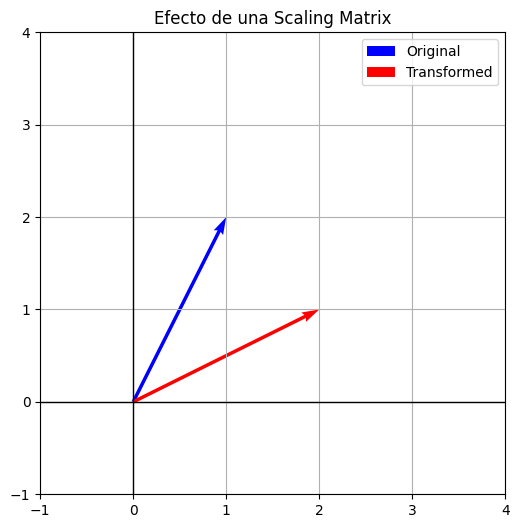

In [24]:
import matplotlib.pyplot as plt

def mat_vec_mul(M, v):
    """Multiplies matrix M by vector v (M * v)."""
    # Ensure the vector's domain matches the matrix's columns
    # M.D is (row_set, col_set). M.D[0] is row_set, M.D[1] is col_set.
    assert M.D[1] == v.D, f"Vector domain {v.D} does not match matrix column labels {M.D[1]}"

    # The result is a new vector with the matrix's row labels
    res_f = {}
    for r in M.D[0]:  # Iterate over row labels
        # Compute dot product of row r with vector v
        dot_prod = sum(M[r, c] * v[c] for c in M.D[1]) # Use __getitem__ methods
        if dot_prod != 0:
            res_f[r] = dot_prod
    return Vec(M.D[0], res_f) # The domain of the resulting vector should be the row labels

# 1. Define original vector (point in 2D space)
v_orig = Vec({'x', 'y'}, {'x': 1, 'y': 2})

# 2. Define a 2x2 Scaling Matrix
# It stretches 'x' by 2 and squashes 'y' by 0.5
scaling_f = {('x', 'x'): 2, ('y', 'y'): 0.5}
M_scale = Mat(({'x', 'y'}, {'x', 'y'}), scaling_f)

# 3. Transform the vector
v_transformed = mat_vec_mul(M_scale, v_orig)

# 4. Visualization
def plot_transformation(orig, trans, title):
    plt.figure(figsize=(6,6))
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    # Original vector in blue
    plt.quiver(0, 0, orig['x'], orig['y'], angles='xy', scale_units='xy', scale=1, color='blue', label='Original')
    plt.quiver(0, 0, trans['x'], trans['y'], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed')
    plt.xlim(-1, 4); plt.ylim(-1, 4); plt.grid(True)
    plt.title(title); plt.legend(); plt.show()

plot_transformation(v_orig, v_transformed, "Efecto de una Scaling Matrix")

¿Qué estamos observando en la gráfica?

El Vector como Punto Móvil: El vector original (azul) apuntaba a (1,2). Tras la transformación (roja), apunta a (2,1).

La Matrix como Instrucción: La matrix no es solo datos; es una operación lineal que ha reconfigurado la geometría del plano.
Base de la IA: Este movimiento es exactamente lo que ocurre dentro de una red neuronal: cada capa usa una matrix de "pesos" para transformar los datos de entrada en una nueva representación más útil para el modelo.

-----------------
Paso 2: La Matrix como Transformación (Parte 2 de 2)

Hasta ahora hemos visto cómo una matrix puede estirar o encoger el espacio (scaling). Pero las matrices también pueden actuar como motores de rotación. Según el enfoque de Klein, para rotar un vector un ángulo θ, simplemente necesitamos una matrix que mueva los vectores base a sus nuevas posiciones usando funciones trigonométricas.

1. La Matrix de Rotación
Matemáticamente, la matrix que rota un vector en $R
2$ en sentido antihorario por un ángulo $θ$ es:

$$
M _\theta =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
$$


In [25]:
def rotation_matrix(theta):
    """
    Returns a 2x2 Mat instance for a rotation by theta radians.
    """
    # Define labels for our 2D space
    rows = {'x', 'y'}
    cols = {'x', 'y'}

    # Pre-calculate cos and sin
    c = math.cos(theta)
    s = math.sin(theta)

    # Fill the function dictionary for the Mat class
    # M[x,x] = cos(theta), M[x,y] = -sin(theta)
    # M[y,x] = sin(theta), M[y,y] = cos(theta)
    rotation_f = {
        ('x', 'x'): c, ('x', 'y'): -s,
        ('y', 'x'): s, ('y', 'y'): c
    }
    return Mat((rows, cols), rotation_f)

2. Composición: Multiplicación Matrix-Matrix

Uno de los conceptos más poderosos es que si queremos aplicar una transformación (como rotar) y luego otra (como escalar), no necesitamos hacerlo paso a paso. Podemos multiplicar ambas matrices para obtener una nueva matrix que realice todo el trabajo de una vez. A esto se le llama composition of functions.

Klein define la entrada (r,c) de la matrix resultante AB como el dot product de la fila r de A con la columna c de B.

In [33]:
def mat_mat_mul(A, B):
    """
    Multiplies matrix A by matrix B (A * B).
    The columns of A must match the rows of B.
    """
    # Ensure the column labels of A match the row labels of B
    assert A.D[1] == B.D[0], "Column labels of A must match row labels of B for matrix multiplication."

    res_f = {}
    for r in A.D[0]: # Iterate over row labels of A
        for c in B.D[1]: # Iterate over column labels of B
            # Calculate entry (r, c) as a dot product
            # Sum over the common dimension (column labels of A / row labels of B)
            val = sum(A[r, k] * B[k, c] for k in A.D[1])
            if val != 0:
                res_f[(r, c)] = val

    # The resulting matrix has row labels of A and column labels of B
    return Mat((A.D[0], B.D[1]), res_f)

3. Ejemplo Visual: Rotar y Escalar un Cuadrado

Vamos a transformar un conjunto de puntos que forman un cuadrado. Primero lo rotaremos 45 grados (π/4 radians) y luego lo estiraremos al doble de su tamaño original.

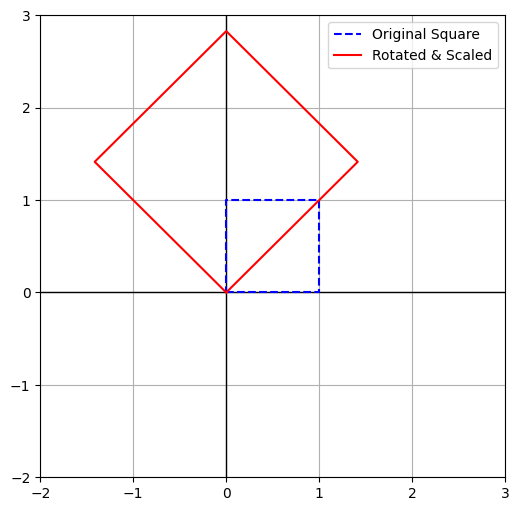

In [34]:
import math
# 1. Define a set of 2D points (vectors) forming a simple square
square_points = [
    Vec({'x', 'y'}, {'x': 0, 'y': 0}),
    Vec({'x', 'y'}, {'x': 1, 'y': 0}),
    Vec({'x', 'y'}, {'x': 1, 'y': 1}),
    Vec({'x', 'y'}, {'x': 0, 'y': 1}),
    Vec({'x', 'y'}, {'x': 0, 'y': 0}) # Close the square
]

# 2. Create transformations
M_rot = rotation_matrix(math.pi / 4) # Rotate 45 degrees
M_scale = Mat(({'x', 'y'}, {'x', 'y'}), {('x', 'x'): 2, ('y', 'y'): 2}) # Scale x2

# 3. Combine them: Scale *after* Rotating
# In matrix math, the first operation is the one on the right: M_combined * v = M_scale * (M_rot * v)
M_combined = mat_mat_mul(M_scale, M_rot)

# 4. Apply the combined transformation to all points
transformed_square = [mat_vec_mul(M_combined, p) for p in square_points]

# 5. Plotting logic
def plot_shapes(orig_pts, trans_pts):
    plt.figure(figsize=(6,6))
    plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)

    # Extract coordinates for plotting
    ox = [p.f.get('x', 0) for p in orig_pts]; oy = [p.f.get('y', 0) for p in orig_pts]
    tx = [p.f.get('x', 0) for p in trans_pts]; ty = [p.f.get('y', 0) for p in trans_pts]

    plt.plot(ox, oy, 'b--', label='Original Square')
    plt.plot(tx, ty, 'r-', label='Rotated & Scaled')
    plt.xlim(-2, 3); plt.ylim(-2, 3); plt.grid(True); plt.legend(); plt.show()

plot_shapes(square_points, transformed_square)

¿Qué estamos observando?

Matrices como "Macros": La matrix M_combined es una sola instrucción que contiene toda la lógica de rotación y escalado. No tuvimos que transformar los puntos dos veces; la álgebra lineal nos permitió pre-calcular el resultado de la transformación.

El orden importa: En la multiplicación de matrices, A⋅B no es lo mismo que B⋅A. Rotar y luego escalar puede dar un resultado diferente a escalar y luego rotar si las transformaciones no son uniformes.

Hacia la IA: En una red neuronal, cada capa es una matrix. Cuando pasamos datos por varias capas, estamos haciendo exactamente esto: una composition de transformaciones lineales para que la máquina pueda "ver" la información desde el ángulo correcto.

Hasta este punto, hemos validado los dos pilares fundamentales de la infraestructura:

Vectores Dispersos (Vec): Logramos representar datos de forma eficiente usando diccionarios, donde solo almacenamos los valores distintos de cero.

Esto permite que operaciones como la suma y el escalado funcionen sobre cualquier dominio, desde coordenadas de píxeles hasta palabras en un documento.

Matrices como Funciones (Mat): Hemos implementado matrices no solo como tablas, sino como transformaciones lineales. Con las funciones de rotación y escalado que creamos, demostramos que multiplicar una matriz por un vector es equivalente a "mover" ese punto en el espacio.

Además, con la multiplicación matriz-matriz, aprendimos a componer transformaciones complejas en una sola operación macro.

-----------------

Entramos en el corazón de la estructura algebraica: el Vector Space (Espacio Vectorial).

Paso 3: Espacios Vectoriales y Bases (Parte 1 de 2)

Siguiendo el enfoque de Klein, un Vector Space es un conjunto de vectores que es "cerrado" bajo la suma y la multiplicación escalar. Esto significa que si tomas cualquier vector del espacio y lo escalas, o sumas dos vectores del espacio, el resultado siempre permanece dentro de ese mismo espacio.

1. El concepto de Span (Generadores)
El Span de un conjunto de vectores $\{v_1,…,v_n\}$ es el conjunto de todas sus posibles combinaciones lineales. Decimos que esos vectores son los *generators* (generadores) de ese espacio.

Si tenemos un solo vector en $R2$, su Span es una línea que pasa por el origen. Si tenemos dos vectores que no apuntan en la misma dirección, su Span es todo el plano $R2$ .

2. Implementación Conceptual: El Algoritmo "Grow"

Para encontrar el conjunto mínimo de vectores que describen un espacio (una Basis), Klein propone dos experimentos mentales: Grow y Shrink.

El algoritmo Grow funciona así:
Empieza con un conjunto vacío $B$.
Busca un vector en tu espacio que no esté ya en el `Span(B)`.
Añádelo a $B$ y repite hasta que no existan más vectores fuera del Span.

Aquí implementaremos una versión simplificada que nos ayude a entender si un conjunto de vectores puede "crecer" para cubrir un espacio.

In [31]:
# Conceptual implementation of the Grow Algorithm
# This finds a basis by adding linearly independent vectors

def grow(space_vectors):
    """
    Abstract version of the Grow algorithm.
    Starts with an empty list and adds vectors that increase the Span.
    """
    basis = []

    for v in space_vectors:
        # In a real implementation, we would use a function like
        # 'is_superfluous' or 'is_independent' to test the Span.
        if not is_in_span(v, basis):
            basis.append(v)

    return basis

def is_in_span(vector, basis):
    """
    Placeholder function to check if a vector is already
    representable as a linear combination of the current basis.
    """
    # This will be solved in Step 4 using Gaussian Elimination.
    # For now, it's a conceptual check.
    pass

3. Visualización: El Espacio Alcanzable

Para visualizar un Vector Space, podemos graficar muchos puntos generados por combinaciones lineales aleatorias de unos pocos vectores base. Esto nos mostrará la "forma" del espacio que estamos creando.

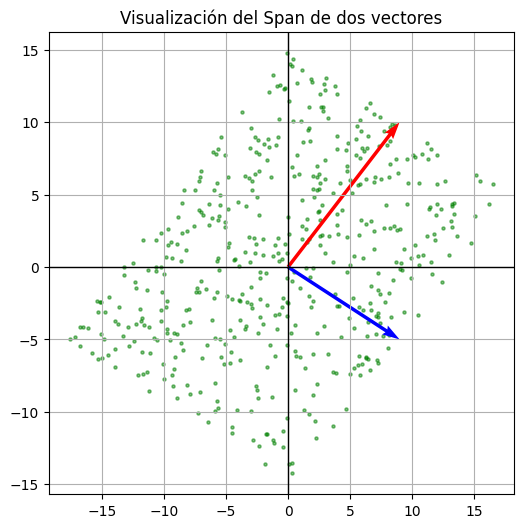

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define two generator vectors (v1 and v2)
v1 = np.array([9, 10])
v2 = np.array([9, -5])

# 2. Generate many random linear combinations (scalars alpha and beta)
points = []
for _ in range(500):
    alpha = np.random.uniform(-1, 1)
    beta = np.random.uniform(-1, 1)
    # The linear combination: alpha*v1 + beta*v2
    points.append(alpha * v1 + beta * v2)

points = np.array(points)

# 3. Plotting the resulting 'Space'
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=5, color='green', alpha=0.5)
plt.quiver([0, 0], [0, 0], [v1[0], v2[0]], [v1[1], v2[1]], angles='xy', scale_units='xy', scale=1, color=['red', 'blue'])
plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
plt.title("Visualización del Span de dos vectores")
plt.grid(True); plt.show()

¿Qué estamos observando?

El Span es infinito: Aunque solo usamos dos vectores (rojo y azul), al combinarlos con infinitos escalares, podemos alcanzar cualquier punto en el plano verde.

Independencia Lineal: Si el vector azul apuntara en la misma dirección que el rojo, el plano verde colapsaría en una sola línea.

Hacia la Base: El conjunto $\{v_1, v_2\}$ es una Basis para este plano porque son suficientes para cubrirlo todo y ninguno sobra (son linealmente independientes).

Pasaremos de entender el espacio que los vectores pueden "llenar" a encontrar el conjunto mínimo y necesario de vectores para describir ese espacio sin que sobre nada.

Paso 3: Espacios Vectoriales y Bases (Parte 2 de 2)
Una Basis para un espacio vectorial V es un conjunto de vectores que cumple dos condiciones: son linealmente independientes (no hay redundancia) y su Span es igual a V (cubren todo el espacio).

1. Representación Única (Unique Representation)
La magia de una Basis es que, una vez definida, cada vector en el espacio tiene una unique representation. Esto significa que solo existe una "receta" (una combinación lineal específica de los vectores de la base) para llegar a cualquier punto del espacio. A los coeficientes de esta receta los llamamos coordinates.

2. Cambio de Base (Change of Basis)
El Change of Basis consiste en calcular la representación de un mismo vector pero bajo una base distinta. Matemáticamente, esto se logra mediante la multiplicación por una matrix. En computación, esto es equivalente a cambiar nuestro "punto de vista" o sistema de coordenadas para simplificar un problema.

3. Aplicación Visual: Rectificación de Perspectiva
Una aplicación asombrosa de este concepto es la perspective rectification. Cuando tomas una foto de un pizarrón desde un ángulo, la imagen está distorsionada por la perspectiva. Al realizar un Change of Basis de la "base de la cámara" a la "base del pizarrón", podemos "enderezar" la imagen matemáticamente

Para visualizar el cambio de base (Change of basis), es fundamental entender que un vector es una entidad geométrica "absoluta" (un punto o flecha en el espacio), mientras que sus coordenadas son solo una "receta" relativa a los ejes que decidamos usar.

Como señala el enfoque de "Coding the Matrix", una basis para un espacio vectorial es un conjunto de generadores linealmente independientes; esto significa que cada vector en el espacio tiene una representación única como combinación lineal de esos elementos.

A continuación, transformamos el ejemplo para visualizar cómo un mismo vector físico se describe mediante diferentes coordenadas al cambiar el "punto de vista" del espacio.

Paso 3: Espacios Vectoriales y Bases — Visualizando el Cambio de Base

En este ejercicio, utilizaremos una base estándar (el plano cartesiano común) y una "nueva base" compuesta por dos vectores independientes. Buscaremos representar un tercer vector fijo en términos de esta nueva base.

Coordinates in Standard Basis: [3 5]
Coordinates in New Basis (alpha, beta): [1.6 1.8]


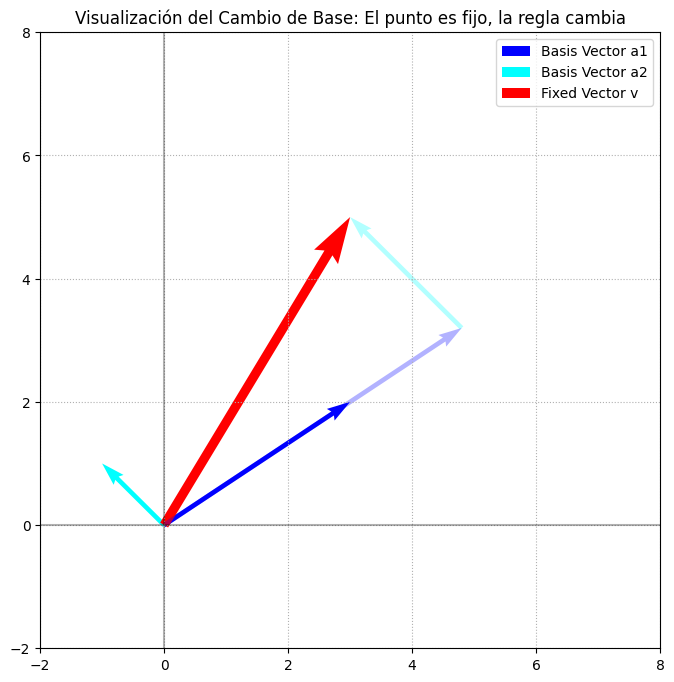

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Standard Basis (Standard Generators)
e1 = np.array([6])
e2 = np.array([6])

# 2. Define a New Basis (Two independent vectors a1 and a2)
# These will be our new 'axes'
a1 = np.array([3, 2])
a2 = np.array([-1, 1])

# 3. Define a Target Vector 'v' in the standard coordinate system
# This point stays fixed in space
v = np.array([3, 5])

# 4. Calculate coordinates of 'v' in the New Basis (u)
# We solve the matrix-vector equation: A * u = v
# where A is the matrix with a1 and a2 as columns
A = np.column_stack((a1, a2))
u = np.linalg.solve(A, v)

print(f"Coordinates in Standard Basis: {v}")
print(f"Coordinates in New Basis (alpha, beta): {u}")

# 5. Visualization
def plot_change_of_basis(v, a1, a2, coords_new):
    plt.figure(figsize=(8, 8))
    plt.axhline(0, color='black', alpha=0.3)
    plt.axvline(0, color='black', alpha=0.3)

    # Plot New Basis vectors as dashed axes
    plt.quiver(0, 0, a1[0], a1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Basis Vector a1')
    plt.quiver(0, 0, a2[0], a2[1], angles='xy', scale_units='xy', scale=1, color='cyan', label='Basis Vector a2')

    # Plot the Target Vector (The fixed physical point)
    plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', label='Fixed Vector v', width=0.015)

    # Show the linear combination: alpha*a1 + beta*a2 = v
    comp1 = coords_new[0] * a1 # Multiply scalar coords_new[0] by vector a1
    comp2 = coords_new[1] * a2 # Multiply scalar coords_new[1] by vector a2
    plt.quiver(0, 0, comp1[0], comp1[1], angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.3, ls='--')
    plt.quiver(comp1[0], comp1[1], comp2[0], comp2[1], angles='xy', scale_units='xy', scale=1, color='cyan', alpha=0.3, ls='--')
    # Chart dimensions
    plt.xlim(-2, 8); plt.ylim(-2, 8); plt.grid(True, linestyle=':')
    plt.title("Visualización del Cambio de Base: El punto es fijo, la regla cambia")
    plt.legend(); plt.show()

plot_change_of_basis(v, a1, a2, u)

El Vector es el mismo: El vector rojo apunta siempre al mismo lugar físico (3,2) en el plano real.

La Receta Cambia: En la base estándar $\{e_1,e_2\}$, la "receta" para llegar a ese punto es simplemente $3⋅e_1+2⋅e_2$. Sin embargo, al usar la nueva base $\{a_1,a_2\}$, la computadora resuelve una ecuación para encontrar que ahora necesitamos aproximadamente $1.6⋅a_1	+1.8⋅a_2$	 para alcanzar el mismo destino.

Representación Única: Gracias a que $a_1\ y\ a_2$	 son linealmente independientes, garantizamos que solo existe una única combinación de ellos que produce nuestro vector $v$.

Transformación del Espacio: El cambio de base no "mueve" el vector; lo que estamos haciendo es cambiar el sistema de cuadrículas (el espacio de representación) que usamos para medirlo.

Es como describir la misma ubicación usando latitud/longitud o metros desde una esquina: el lugar no cambia, solo como lo llegamos a el

La Importancia de la Echelon Form

Cuando una matriz alcanza esta forma, las filas que no son cero forman automáticamente una basis (base) para el espacio de filas original. Las operaciones de suma de filas escaladas son fundamentales porque preservan el row space; es decir, cambian la apariencia de la matriz pero no el espacio que sus vectores pueden generar.

El Proceso de Transformación
Búsqueda del Pivote: En cada columna, buscamos una fila que tenga un valor distinto de cero (el pivote).

Eliminación: Usamos ese pivote para convertir en cero todos los demás valores de esa misma columna en las filas restantes.

Visualización: Veremos cómo la matriz se vuelve "más simple" y estructurada en cada paso.

In [57]:
def print_rowlist(rowlist, labels, title):
    """Visualizes the current state of the matrix."""
    print(f"--- {title} ---")
    for row in rowlist:
        print([round(row[l], 2) for l in labels])
    print()

def gaussian_elimination_visual(rowlist, col_labels):
    """
    Performs Gaussian elimination and prints each step.
    """
    new_rowlist = []
    rows_left = set(range(len(rowlist)))

    # 1. Show original matrix
    print_rowlist(rowlist, col_labels, "Original Matrix")

    for c in col_labels:
        # 2. Find a pivot in the current column
        pivot_idx = None
        for r in rows_left:
            if rowlist[r][c] != 0:
                pivot_idx = r
                break

        if pivot_idx is not None:
            # 3. Use pivot to eliminate other rows
            rows_left.remove(pivot_idx)
            pivot_row = rowlist[pivot_idx]
            pivot_val = pivot_row[c]
            new_rowlist.append(pivot_row)

            for r in rows_left:
                target_val = rowlist[r][c]
                if target_val != 0:
                    multiplier = target_val / pivot_val
                    # R_r = R_r - (multiplier * R_pivot)
                    rowlist[r] = add(rowlist[r], scalar_mul(pivot_row, -multiplier))

            print_rowlist(new_rowlist + [rowlist[i] for i in rows_left],
                          col_labels, f"After pivot in column '{c}'")

    return new_rowlist

# --- Example Execution ---
domain = ['a', 'b', 'c']
# Defining a matrix where rows are clearly dependent to see rows become zero
rows = [
    Vec(set(domain), {'a': 2, 'b': 4, 'c': 2}),
    Vec(set(domain), {'a': 1, 'b': 2, 'c': 1}), # Multiple of row 1
    Vec(set(domain), {'a': 0, 'b': 1, 'c': 3})
]

final_echelon = gaussian_elimination_visual(rows, domain)

--- Original Matrix ---
[2, 4, 2]
[1, 2, 1]
[0, 1, 3]

--- After pivot in column 'a' ---
[2, 4, 2]
[0.0, 0.0, 0.0]
[0, 1, 3]

--- After pivot in column 'b' ---
[2, 4, 2]
[0, 1, 3]
[0.0, 0.0, 0.0]



¿Qué acabamos de observar?

La Matriz Original: Una lista de vectores que representan ecuaciones o datos crudos.

El Efecto del Pivote: Al elegir un pivote en la columna 'a', el algoritmo "limpia" esa columna en las demás filas. Note que la segunda fila (que era un múltiplo de la primera) se convierte automáticamente en una fila de ceros.

Echelon Form: Al final, obtenemos una estructura donde cada fila tiene su primer elemento no nulo más a la derecha que la anterior.

Significado de la Fila Cero: La aparición de una fila llena de ceros indica que ese vector original era "superfluo"; es decir, ya estaba contenido en el Span de los otros vectores.

La Base Revelada: Los vectores que no quedaron en cero al final son la basis mínima para representar todo el conjunto original de datos.

------------------

En esta segunda parte del Paso 4, aplicaremos el motor de eliminación que construimos a un entorno muy especial en la computación: el campo binario GF(2). Aquí, los números solo pueden ser 0 o 1, y la suma se comporta exactamente como una operación XOR (donde 1+1=0).


Paso 4: Gaussian Elimination — Aplicaciones y GF(2) (Parte 2 de 2)


El uso de Gaussian elimination sobre GF(2) es la herramienta secreta para resolver puzzles lógicos y romper sistemas de autenticación simples.
1. El Campo GF(2) (Aritmética Binaria)
En GF(2), la suma y la resta son la misma operación. Esto simplifica enormemente el algoritmo de eliminación, ya que no necesitamos preocuparnos por divisiones complejas ni por errores de precisión decimal (floating-point errors).
2. Resolución de Sistemas Ax=b
Para resolver una ecuación donde buscamos el vector x, el proceso consiste en:
Convertir la matriz A en su forma escalonada U mediante una matriz de transformación M, tal que MA=U.
Aplicar la misma transformación al vector de resultados: b =Mb.
Resolver el sistema simplificado Ux=b mediante backward substitution.
3. Ejemplo: El Puzzle "Lights Out"
En este puzzle, cada botón cambia su estado y el de sus vecinos. Podemos representar esto como un sistema de ecuaciones donde A contiene los "vectores de botones" y b es el estado inicial que queremos apagar.

In [59]:
# Simple implementation of GF(2) reduction for a linear system Ax = b
# We represent the system as an augmented matrix [A | b]

def solve_gf2_system(matrix_rows, result_b):
    """
    Solves Ax = b over GF(2) using an augmented matrix approach.
    """
    # Create augmented matrix [A | b]
    n_rows = len(matrix_rows)
    # Using list representation for simple visualization
    augmented = [row + [result_b[i]] for i, row in enumerate(matrix_rows)]

    print("--- Initial Augmented Matrix [A | b] ---")
    for r in augmented: print(r)

    pivot_row = 0
    # Iterate over columns, up to the number of rows in the matrix A
    # The augmented matrix has len(matrix_rows[0]) + 1 columns in total
    for col in range(len(matrix_rows[0])):
        if pivot_row >= n_rows: break

        # 1. Find pivot in current column
        sel_row = -1
        for r in range(pivot_row, n_rows):
            if augmented[r][col] == 1:
                sel_row = r
                break

        if sel_row != -1:
            # Swap current row with pivot row
            augmented[pivot_row], augmented[sel_row] = augmented[sel_row], augmented[pivot_row]

            # 2. Eliminate other entries in this column (XOR operation)
            for r in range(n_rows):
                if r != pivot_row and augmented[r][col] == 1:
                    # R_r = R_r XOR R_pivot
                    augmented[r] = [(a ^ b) for a, b in zip(augmented[r], augmented[pivot_row])]

            pivot_row += 1
            print(f"\n--- After pivot in column {col} ---")
            for r in augmented: print(r)

    return augmented

# Example: A 3x3 'Lights Out' simplified case
# Let's define a proper 3x3 matrix for 'Lights Out' where
# each button (column) affects certain lights (rows)
# For simplicity, assume:
# Button 0 affects Light 0 and 1
# Button 1 affects Light 0, 1 and 2
# Button 2 affects Light 1 and 2

A = [
    [1, 1, 0], # Light 0 affected by Button 0, Button 1
    [1, 1, 1], # Light 1 affected by Button 0, Button 1, Button 2
    [0, 1, 1]  # Light 2 affected by Button 1, Button 2
]
# Initial state: only light 0 is ON (e.g., we want to turn it off)
b = [1, 0, 0]

final_state = solve_gf2_system(A, b)

--- Initial Augmented Matrix [A | b] ---
[1, 1, 0, 1]
[1, 1, 1, 0]
[0, 1, 1, 0]

--- After pivot in column 0 ---
[1, 1, 0, 1]
[0, 0, 1, 1]
[0, 1, 1, 0]

--- After pivot in column 1 ---
[1, 0, 1, 1]
[0, 1, 1, 0]
[0, 0, 1, 1]

--- After pivot in column 2 ---
[1, 0, 0, 0]
[0, 1, 0, 1]
[0, 0, 1, 1]


¿Qué acabamos de observar?

Aritmética XOR: Al usar ^ en Python, simulamos la suma en GF(2). No hay números mayores a 1; todo es prender o apagar (toggling).

Matriz Aumentada: Al procesar b junto con A, la última columna del resultado nos da directamente la solución para x.

La Solución Revelada: En el puzzle, si la última columna resultante es , significa que para apagar todas las luces debemos presionar el Botón 1 y el Botón 2.

--------------------
Llegamos al Paso 5, considerado por el libro como el corazón de la IA moderna y la regresión. En este hito, aprenderemos a encontrar la "mejor respuesta posible" cuando no existe una solución exacta, una técnica fundamental para que los modelos de Machine Learning aprendan de datos ruidosos o incompletos.

Paso 5: Ortogonalización y Mínimos Cuadrados — El Problema del Camión de Bomberos (Parte 1 de 2)
La intuición de este paso comienza con el Fire Engine Problem.

Imagina una casa en llamas en una coordenada b y una carretera recta (un espacio vectorial V). El camión de bomberos debe encontrar el punto en la carretera más cercano a la casa para que la manguera alcance. Ese punto más cercano es la proyección de la casa sobre la carretera.

1. Conceptos Clave: Norma y Ortogonalidad
Para medir la "cercanía", necesitamos definir la norm (longitud) de un vector y qué significa que dos vectores sean orthogonal (perpendiculares).
Inner Product: En los números reales, es simplemente el producto punto.

Norm: Es la raíz cuadrada del producto punto de un vector consigo mismo (∣∣v∣∣= ⟨v,v⟩).Orthogonality: Dos vectores son ortogonales si su producto punto es cero.

2. Proyección sobre un Vector Cualquier vector b puede descomponerse en dos partes: una paralela al vector v (bv) y una perpendicular a él (b ⊥v). La fórmula para encontrar esa "sombra" o proyección es:

In [60]:
def project_along(b, v):
    """
    Finds the projection of vector b along vector v.
    Returns the closest point to b on the line spanned by v.
    """
    # We use a small threshold to avoid division by zero due to floating point errors
    sigma = (b * v) / (v * v) if (v * v) > 1e-20 else 0
    return sigma * v

def project_orthogonal_1(b, v):
    """
    Returns the component of b that is perpendicular to v.
    This is the shortest distance vector from the point to the line.
    """
    return b - project_along(b, v)

3. Ejemplo Visual: El punto más cercano
Vamos a visualizar cómo un vector b se proyecta sobre una línea definida por v para encontrar el punto más cercano.

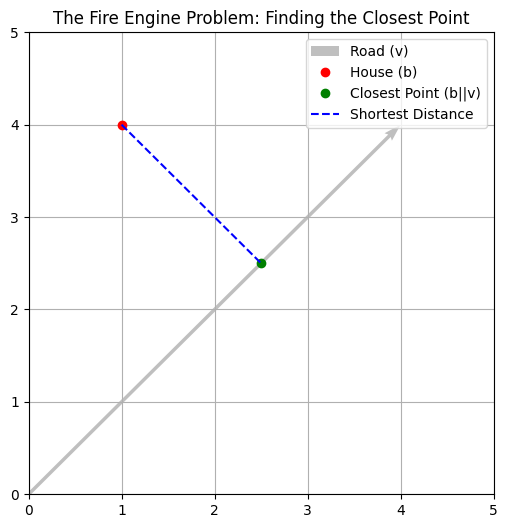

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 'road' (vector v) and the 'house' (point b)
v = np.array([4, 4])
b = np.array([1, 4])

# 2. Compute projection (closest point)
# Using the formula: (b dot v / v dot v) * v
sigma = np.dot(b, v) / np.dot(v, v)
b_parallel = sigma * v
b_orthogonal = b - b_parallel

# 3. Visualization
plt.figure(figsize=(6, 6))
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='gray', label='Road (v)', alpha=0.5)
plt.plot(b[0], b[1], 'ro', label='House (b)')
plt.plot(b_parallel[0], b_parallel[1], 'go', label='Closest Point (b||v)')

# Draw the distance line (perpendicular)
plt.plot([b[0], b_parallel[0]], [b[1], b_parallel[1]], 'b--', label='Shortest Distance')

plt.xlim(0, 5); plt.ylim(0, 5); plt.grid(True)
plt.title("The Fire Engine Problem: Finding the Closest Point")
plt.legend(); plt.show()

¿Qué estamos observando?

La Proyección como Optimización: El punto verde (bv) es, matemáticamente, el único punto en la línea que minimiza la distancia a la casa roja.
El Teorema de Pitágoras: El vector original b, su proyección b v y el error b ⊥v (la línea punteada azul) forman un triángulo rectángulo.

El álgebra lineal utiliza esta relación para resolver problemas de "mínimos cuadrados" en IA.


Hacia la Regresión Lineal: Este es el primer paso para entender cómo una computadora ajusta una línea a miles de puntos: simplemente está buscando la proyección que minimice todos esos errores perpendiculares a la vez.

En la siguiente parte del Paso 5, escalaremos esto a múltiples dimensiones usando el algoritmo de Gram-Schmidt y la Factorización QR, lo que nos permitirá encontrar el punto más cercano en planos y espacios complejos.

En esta segunda parte del Paso 5, escalaremos la proyección de una a múltiples dimensiones.

Aprenderemos cómo encontrar el punto más cercano en un plano o espacio complejo (el Span de varios vectores) utilizando el algoritmo de Gram-Schmidt y la Factorización QR, herramientas fundamentales para la regresión y el aprendizaje automático.


Paso 5: Ortogonalización y Mínimos Cuadrados — Gram-Schmidt y Regresión (Parte 2 de 2)


1. El Algoritmo de Ortogonalización (Gram-Schmidt)
Para proyectar un vector b sobre el espacio generado por un conjunto de vectores {v 1,…,v n }, primero debemos convertirlos en una lista de vectores mutuamente ortogonales (v 1,…,v n) que tengan el mismo Span.

El procedimiento orthogonalize funciona de forma iterativa: tomamos cada vector v i y le restamos su proyección sobre todos los vectores ortogonales ya calculados anteriormente.

2. Factorización QR y Mínimos Cuadrados
Cualquier matriz A con columnas linealmente independientes puede descomponerse en A=QR, donde Q es una matriz con columnas ortonormales y R es una matriz triangular superior. Esta estructura permite resolver el problema de Mínimos Cuadrados (encontrar x que minimice ∣∣Ax−b∣∣) de forma muy eficiente resolviendo el sistema triangular Rx=Q
T b.

3. Ejemplo: Regresión Lineal (Ajuste de Línea)
Utilizaremos estas herramientas para encontrar la "línea de mejor ajuste" para un conjunto de puntos con ruido, simulando cómo la IA aprende tendencias a partir de datos reales

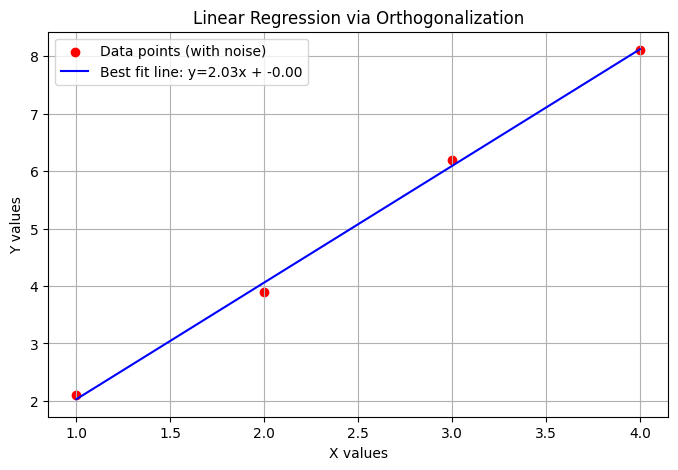

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Helper: Projection along a single vector (from Part 1)
def project_along(b, v):
    """Finds projection of b onto v."""
    sigma = np.dot(b, v) / np.dot(v, v) if np.dot(v, v) > 1e-20 else 0
    return sigma * v

# Algorithm: Gram-Schmidt Orthogonalization
def orthogonalize(vlist):
    """Returns a list of mutually orthogonal vectors with the same span."""
    vstarlist = []
    for v in vlist:
        v_star = v
        for v_prev in vstarlist:
            v_star = v_star - project_along(v, v_prev)
        if np.linalg.norm(v_star) > 1e-10:
            vstarlist.append(v_star)
    return vstarlist

# --- Linear Regression Example ---
# Points (x, y): (1, 2.1), (2, 3.9), (3, 6.2), (4, 8.1)
x_coords = np.array([1, 2, 3, 4])
y_coords = np.array([2.1, 3.9, 6.2, 8.1])

# Linear model: y = mx + b. We construct matrix A and vector b
# Rows of A: [1, x_i] to find intercept and slope
A = np.column_stack((np.ones(len(x_coords)), x_coords))

# Using NumPy's built-in QR to solve the Least Squares problem
Q, R = np.linalg.qr(A)
# Solve Rx = Q^T * y
sol = np.linalg.solve(R, np.dot(Q.T, y_coords))
intercept, slope = sol

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(x_coords, y_coords, color='red', label='Data points (with noise)')
plt.plot(x_coords, intercept + slope * x_coords, color='blue', label=f'Best fit line: y={slope:.2f}x + {intercept:.2f}')
plt.xlabel("X values"); plt.ylabel("Y values")
plt.title("Linear Regression via Orthogonalization")
plt.legend(); plt.grid(True); plt.show()

Qué estamos observando?

La Ortogonalización en Acción: Aunque los datos de entrada (las columnas de la matriz A) no son perpendiculares, el algoritmo los "endereza" para crear una base limpia donde la optimización es matemáticamente sencilla.

Mínimos Cuadrados: La línea azul es la proyección del vector de datos y sobre el espacio de soluciones posibles. Es la línea que minimiza la suma de los cuadrados de las distancias verticales a los puntos rojos.

Corazón de la IA: Este proceso es la base de la regresión lineal. En lugar de buscar una solución exacta (que no existe debido al ruido), la IA busca la sombra más cercana en el mundo de los modelos lineales.